# Instalaciones

In [1]:
# %pip install jenkspy
# %pip install scikit-posthocs
# %pip install jinja2



## Importaciones

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
import jenkspy
import scikit_posthocs as sp
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor


## Carga del Dataset

In [6]:
df = pd.read_csv("../Data/data_cleaning_2026_04_05.csv")

In [7]:
df.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota',
       'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo',
       'indicador_enfermedad', 'motivo_ausencia_mapeado',
       'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='object')

## Transformación de datos

In [8]:
df_clean = df.loc[:, ~df.columns.isin(['mascota', 'peso', 'estatura'])]

In [12]:
df_clean[df_clean['horas_ausentismo'] == 0]

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
662,36,0,7.0,Martes,Verano,118,13,18,50,239.554,...,1,1,1,0,31,0,NaN,NaN,Julio,Bachillerato
663,20,0,9.0,Lunes,Primavera,260,50,11,36,241.476,...,1,4,1,0,23,0,NaN,NaN,Septiembre,Bachillerato
664,29,0,9.0,Lunes,Primavera,225,26,9,28,241.476,...,1,1,0,0,24,0,NaN,NaN,Septiembre,Bachillerato
665,11,0,9.0,Martes,Primavera,289,36,13,33,241.476,...,1,2,1,0,30,0,NaN,NaN,Septiembre,Bachillerato
666,36,0,9.0,Martes,Primavera,118,13,18,50,241.476,...,1,1,1,0,31,0,NaN,NaN,Septiembre,Bachillerato
667,13,0,9.0,Miercoles,Primavera,369,17,12,31,241.476,...,1,3,1,0,25,0,NaN,NaN,Septiembre,Bachillerato
668,36,0,10.0,Miercoles,Primavera,118,13,18,50,253.465,...,1,1,1,0,31,0,NaN,NaN,Octubre,Bachillerato
669,34,27,1.0,Lunes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,0,No Enfermedad,Fisioterapia,Enero,Bachillerato
670,2,0,4.0,Lunes,Invierno,235,29,12,48,326.452,...,1,1,0,1,33,0,NaN,NaN,Abril,Bachillerato
671,7,0,5.0,Miercoles,Invierno,279,5,14,39,378.884,...,1,2,1,1,24,0,NaN,NaN,Mayo,Bachillerato


Miro cuantos registro sin horas y sin faltas hay

In [15]:
df_clean[(df_clean['horas_ausentismo'] == 0) & (df_clean['falta_disciplinaria'] == 0)]

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
669,34,27,1.0,Lunes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,0,No Enfermedad,Fisioterapia,Enero,Bachillerato
703,4,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato
704,8,0,NaN,Miercoles,Otoño,231,35,14,39,271.219,...,1,2,1,0,35,0,NaN,NaN,NaN,Bachillerato
705,35,0,NaN,Viernes,Invierno,179,45,14,53,271.219,...,1,1,0,0,25,0,NaN,NaN,NaN,Bachillerato
743,74,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato
1021,352,0,NaN,Martes,Verano,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,Bachillerato


In [16]:
df_clean

,id,motivo_ausencia,mes_ausencia,dia_semana,estaciones,gasto_transporte,distancia_casa_trabajo,tiempo_servicio,edad,carga_trabajo_diaria,...,educacion,hijos,bebedor_social,fumador_social,indice_masa_corporal,horas_ausentismo,indicador_enfermedad,motivo_ausencia_mapeado,mes_ausencia_mapeado,educacion_mapeada
0,14,11,11.0,Lunes,Primavera,155,12,14,34,284.031,...,1,2,1,0,25,120,Enfermedad,Sistema Digestivo,Noviembre,Bachillerato
1,36,13,4.0,Miercoles,Invierno,118,13,18,50,239.409,...,1,1,1,0,31,120,Enfermedad,Sistema Osteomuscular,Abril,Bachillerato
2,9,6,7.0,Martes,Verano,228,14,16,58,264.604,...,1,2,0,0,22,120,Enfermedad,Sistema Nervioso,Julio,Bachillerato
3,28,9,7.0,Martes,Verano,225,26,9,28,230.290,...,1,1,0,0,24,112,Enfermedad,Sistema Circulatorio,Julio,Bachillerato
4,9,12,3.0,Martes,Otoño,228,14,16,58,222.196,...,1,2,0,0,22,112,Enfermedad,Piel y Tejido Subcutáneo,Marzo,Bachillerato
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,382,27,1.0,Miercoles,Otoño,179,26,9,30,313.532,...,3,0,0,0,19,2,No Enfermedad,Fisioterapia,Enero,Posgrado
1052,383,26,8.0,Martes,Verano,289,36,13,33,249.797,...,1,2,1,0,30,8,No Enfermedad,Falta injustificada,Agosto,Bachillerato
1053,384,18,1.0,Martes,Otoño,155,12,14,34,313.532,...,1,2,1,0,25,8,Enfermedad,Síntomas y Hallazgos Clínicos,Enero,Bachillerato
1054,385,27,1.0,Martes,Otoño,118,10,10,37,308.593,...,1,0,0,0,28,1,No Enfermedad,Fisioterapia,Enero,Bachillerato


## Quito lineas de hausencia en 0 horas y con falta disciplinarias ausentes (menos 5 empleados)

In [17]:
df_clean = df_clean[(df_clean['horas_ausentismo'] > 0) | (df_clean['falta_disciplinaria'] > 0)]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1050 entries, 0 to 1055
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1050 non-null   int64  
 1   motivo_ausencia          1050 non-null   int64  
 2   mes_ausencia             1050 non-null   float64
 3   dia_semana               1050 non-null   object 
 4   estaciones               1050 non-null   object 
 5   gasto_transporte         1050 non-null   int64  
 6   distancia_casa_trabajo   1050 non-null   int64  
 7   tiempo_servicio          1050 non-null   int64  
 8   edad                     1050 non-null   int64  
 9   carga_trabajo_diaria     1050 non-null   float64
 10  cumplimiento_objetivo    1050 non-null   int64  
 11  falta_disciplinaria      1050 non-null   int64  
 12  educacion                1050 non-null   int64  
 13  hijos                    1050 non-null   int64  
 14  bebedor_social           1050

# Análisis descriptiva inicial

### Variables clave para responder a la pregunta:
#### - bebedor_social (0/1)
#### - fumador_social (0/1)
#### - falta_disciplinaria (0/1 o conteo)
#### - horas_ausentismo (variable dependiente)



===== Distribución de horas de absentismo según bebedor_social =====
                count      mean        std  min  25%  50%  75%    max
bebedor_social                                                       
0               468.0  6.286325  13.385219  0.0  2.0  3.0  8.0  120.0
1               588.0  8.447279  16.005608  0.0  2.0  4.0  8.0  120.0


===== Distribución de horas de absentismo según fumador_social =====
                count      mean        std  min  25%  50%  75%    max
fumador_social                                                       
0               983.0  7.564598  15.247304  0.0  2.0  3.0  8.0  120.0
1                73.0  6.479452   9.781089  0.0  2.0  3.0  8.0   64.0


===== Distribución de horas de absentismo según falta_disciplinaria =====
                      count      mean        std  min  25%  50%  75%    max
falta_disciplinaria                                                        
0                    1006.0  7.861829  15.204078  0.0  2.0  3.0  8.0  

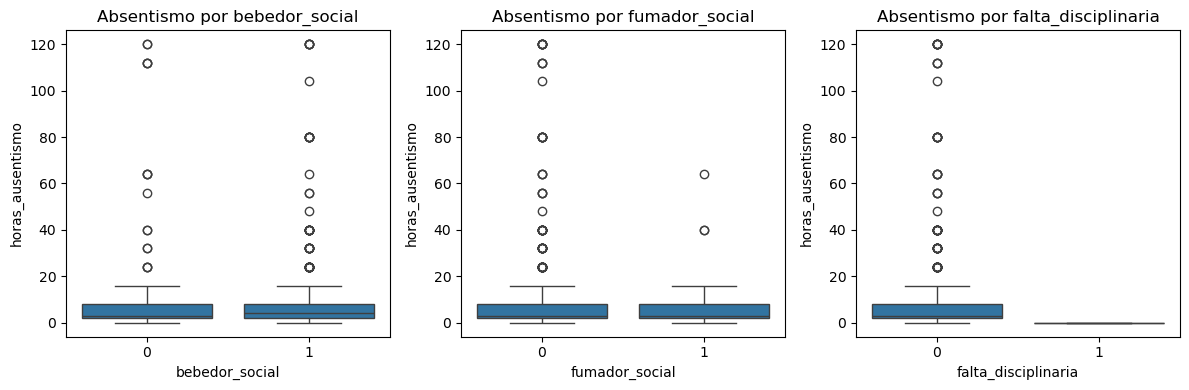

In [19]:
# 3. Análisis descriptivo
# ============================================================

# --- Estadísticos descriptivos por grupo ---
variables_estudio = ["bebedor_social", "fumador_social", "falta_disciplinaria"]

for var in variables_estudio:
    print(f"\n\n===== Distribución de horas de absentismo según {var} =====")
    print(df.groupby(var)["horas_ausentismo"].describe())

# --- Boxplots comparativos ---
plt.figure(figsize=(12,4))
for i, var in enumerate(variables_estudio, 1):
    plt.subplot(1,3,i)
    sns.boxplot(data=df, x=var, y="horas_ausentismo")
    plt.title(f"Absentismo por {var}")
plt.tight_layout()
plt.show()


## Pruebas Estadísticas no paramétricas
## Mann-Whitney U - **variables binarias**

In [46]:
# 4. Pruebas estadísticas no paramétricas
# ============================================================

# --- Mann–Whitney U para variables binarias ---
for var in variables_estudio:
    grupo1 = df[df[var] == 1]["horas_ausentismo"]
    grupo0 = df[df[var] == 0]["horas_ausentismo"]

    stat, p = stats.mannwhitneyu(grupo1, grupo0, alternative="two-sided")
    print(f"\nMann–Whitney U para {var}: U={stat:.2f}, p={p:.5f}")

# --- Correlación Spearman si falta_disciplinaria es numérica ---
if df["falta_disciplinaria"].nunique() > 2:
    rho, p = spearmanr(df["falta_disciplinaria"], df["horas_ausentismo"])
    print(f"\nCorrelación Spearman (falta_disciplinaria vs horas_ausentismo): rho={rho:.3f}, p={p:.5f}")




Mann–Whitney U para bebedor_social: U=88835.00, p=0.00445

Mann–Whitney U para fumador_social: U=21417.00, p=0.96643

Mann–Whitney U para falta_disciplinaria: U=110.00, p=0.00000


## Modelo Multivariable
## Regresión OLS

In [49]:
# 5. Modelo multivariable (Regresión OLS)
# ============================================================

# Fórmula del modelo:
# Incluimos variables de control relevantes para evitar sesgos:
# edad, carga_trabajo_diaria, hijos, tiempo_servicio, motivo_ausencia_mapeado

modelo = smf.ols(
    "horas_ausentismo ~ bebedor_social + fumador_social + falta_disciplinaria + edad + carga_trabajo_diaria + hijos + tiempo_servicio + C(motivo_ausencia_mapeado)",
    data=df
).fit()

print("\n\n===== Resultados del modelo OLS =====")
print(modelo.summary())




===== Resultados del modelo OLS =====
                            OLS Regression Results                            
Dep. Variable:       horas_ausentismo   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     5.973
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.75e-21
Time:                        23:21:48   Log-Likelihood:                -3039.1
No. Observations:                 758   AIC:                             6144.
Df Residuals:                     725   BIC:                             6297.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

## Ramdom Forest



===== Importancia de variables (Random Forest) =====
carga_trabajo_diaria    0.629279
edad                    0.174328
tiempo_servicio         0.090548
hijos                   0.067991
bebedor_social          0.016354
falta_disciplinaria     0.015227
fumador_social          0.006273
dtype: float64


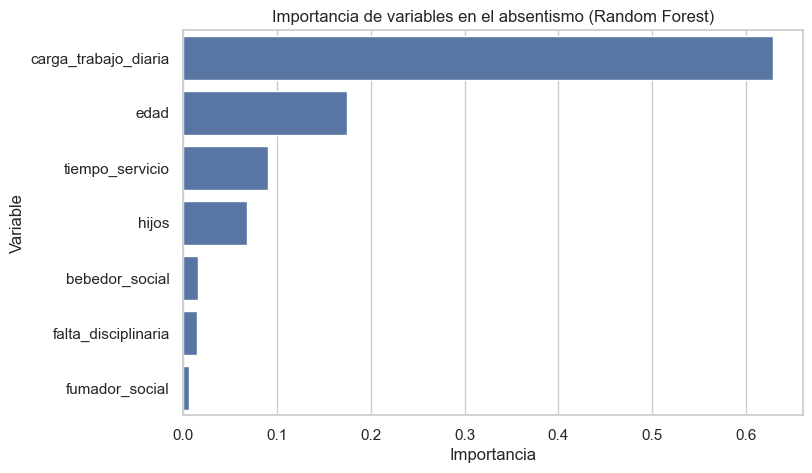

In [52]:
# 6. Importancia de variables (Random Forest)
# ============================================================

# Selección de variables numéricas para el modelo
X = df[["bebedor_social", "fumador_social", "falta_disciplinaria",
        "edad", "carga_trabajo_diaria", "hijos", "tiempo_servicio"]]

y = df["horas_ausentismo"]

# Entrenamiento del modelo
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n\n===== Importancia de variables (Random Forest) =====")
print(importancias)

# --- Visualización ---
plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title("Importancia de variables en el absentismo (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


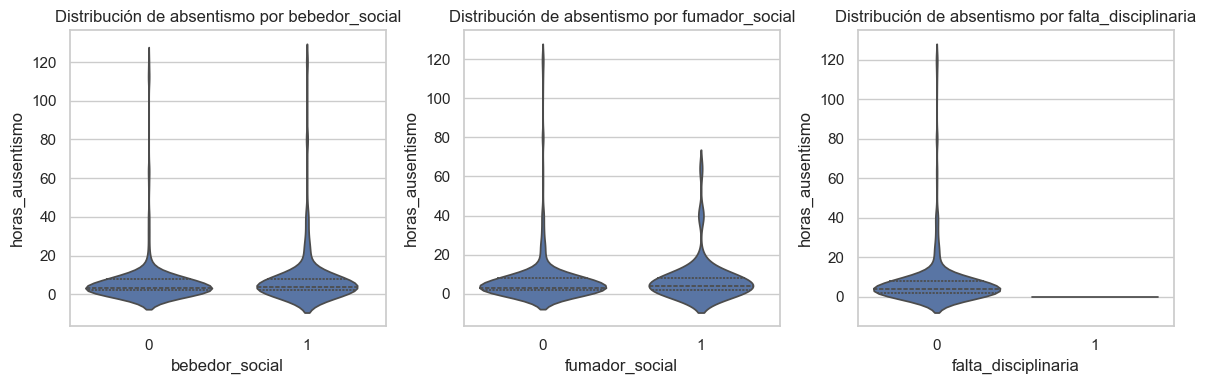

In [53]:
# 7. Visualización adicional: violines
# ============================================================

plt.figure(figsize=(12,4))
for i, var in enumerate(variables_estudio, 1):
    plt.subplot(1,3,i)
    sns.violinplot(data=df, x=var, y="horas_ausentismo", inner="quartile")
    plt.title(f"Distribución de absentismo por {var}")
plt.tight_layout()
plt.show()
